# Packages

In [70]:
import numpy as np
from tp_perceptron_source import predict, mse_loss, zero_one_loss
import matplotlib.pyplot as plt

# L'essentiel de la fonction de coût

**Explication de la fonction de perte**

Soit :  
- \( R \) la valeur prédite par le modèle,  
- \( Y \) la valeur réelle (ou l’étiquette),  
- \( R^+ \) la mesure de l’erreur ou de la perte résultant de la différence entre la prédiction et la valeur réelle.

La fonction de perte quantifie donc le "coût" d’une prédiction incorrecte ou inexacte.  
**Elle est souvent exprimée en fonction d'une distance ou d'une divergence entre \( R \) et \( Y \)**, par exemple :

$$
\ell(R, Y) = |R - Y|
$$

Plus exactement, le coût que l’on veut minimiser en fonction de \( w \) est **l’espérance de la fonction de perte** sur l’ensemble des données :

$$
\mathbb{E}[\ell(f^w(x), y)]
$$

où :
- \( f^w(x) \) est la **fonction de décision** (la prédiction du modèle),
- \( y \) est la **valeur réelle**,
- et \( w \) représente les **paramètres du modèle**, sur lesquels on effectue l’optimisation.

Il s’agit de minimiser l’écart entre le résultat de la fonction de décision pour chaque entrée \( x \), et a valeur réelle \( y \).
a valeur réelle \( y \).
valeur éelle \( y \).
éelle \( y \).
éelle \( y \).


## 3. Nature des fonctions

### 3.1.Essaie personnelle sur la fonction perte erreur quadratique MSE

D'une manière générale, la nature d'une fonction est visible à travers sa représentation graphique. Voilà pourquoi on a choisi de se procéder à la représentation graphique du MSE suivant : 

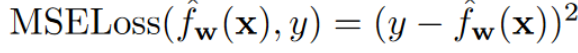

Pour ce faire, il nous faut une donnée d'entrée X pour calculer la fonction de décision. De même, il est nécessaire d'avoir Y, la valeur réelle à prédire par la fonction de décision. On termine avec le calcul de l'écart entre y et la fonction de décision à chaque observation afin de représenter graphiquement ces écarts.

In [14]:
# Importer le fichier .npz
data = np.load('jeu_de_donnees.npz')

# Accéder aux variables individuellement
X_bi_gauss = data['X_bi_gauss']
Y_bi_gauss = data['Y_bi_gauss']
X_clown    = data['X_clown']
Y_clown    = data['Y_clown']
X_chekers  = data['X_chekers']
Y_chekers  = data['Y_chekers']

In [20]:
# Données : 
X_bi_gauss
Y_bi_gauss

# Création de w
print(X_bi_gauss.shape)

(40, 2)


In [ ]:
## La forme de X_bi_gauss est (40, 2), nous créons donc w avec la forme (3,) pour correspondre à 2 caractéristiques + 1 pour le biais
w = np.random.randn(3)  # Cela inclut deux poids et un terme de biais

In [43]:
# Appel de la fonction de la prédiction
decision_scores = predict(X_bi_gauss, w)
print(decision_scores)

[ 0.44014264  0.41138137 -0.31907945 -3.37156097  0.15548786  0.26440275
 -0.88668683 -0.82488229 -1.00274522  0.42236999 -1.756619   -2.07208373
 -1.68163562 -1.10141817  0.85080842  0.42642779 -1.63005961 -0.78182361
 -2.70865714  0.88419452 -0.05521212 -1.87853051 -1.59114878 -1.48009742
  0.01343458 -0.15215902 -1.42660538  0.78432173 -1.17446637 -2.38230689
  0.17684024 -0.19474167  0.6775468   0.28244512  0.07805433 -1.93366596
 -0.25878763 -1.49682966  0.02828634  0.78905006]


In [44]:
X_bi_gauss_with_bias[:5]

array([[ 1.        ,  2.76166474,  1.60752972],
       [ 1.        ,  0.38061206,  1.48737837],
       [ 1.        , -1.54308813,  0.51186473],
       [ 1.        , -3.61747873, -3.35316736],
       [ 1.        ,  1.85863126,  1.22194118]])

In [57]:
mse = mse_loss(X_bi_gauss, Y_bi_gauss, w)
mse

array([0.31344026, 0.34647189, 0.4636528 , 5.62430145, 0.71320075,
       0.54110331, 0.01283988, 3.33019537, 4.0109884 , 0.33365642,
       0.57247231, 1.14936353, 0.46462712, 0.01028565, 0.02225813,
       0.32898508, 0.39697511, 0.04760094, 2.91950921, 0.01341091,
       1.11347261, 0.77181586, 0.34945689, 0.23049353, 0.97331134,
       1.32747041, 0.18199215, 0.04651712, 0.03043851, 1.91077233,
       0.67759199, 0.64844098, 0.10397607, 0.51488501, 0.84998382,
       0.87173212, 1.5845463 , 0.24683971, 1.05737281, 0.04449988])

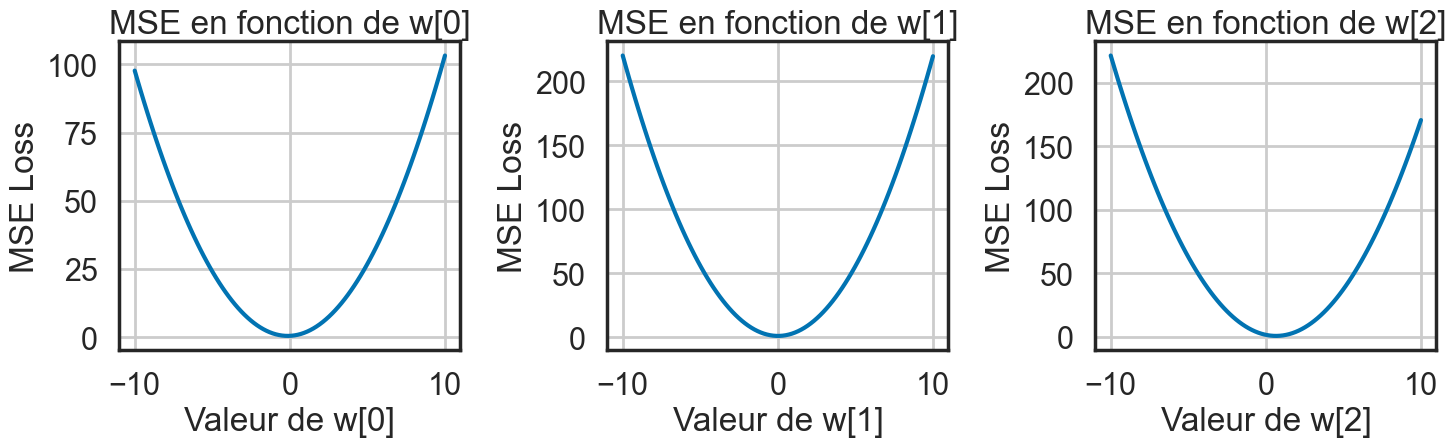

In [76]:
# Création des subplots
fig, axes = plt.subplots(1, len(w), figsize=(15, 5))

for i in range(len(w)):
    weight_values = np.linspace(-10, 10, 100)
    MSE_losses = []

    for val in weight_values:
        w_temp = w.copy()
        w_temp[i] = val
        mse = mse_loss(X_bi_gauss, Y_bi_gauss, w_temp)
        MSE_losses.append(np.mean(mse))

    axes[i].plot(weight_values, MSE_losses)
    axes[i].set_xlabel(f'Valeur de w[{i}]')
    axes[i].set_ylabel('MSE Loss')
    axes[i].set_title(f'MSE en fonction de w[{i}]')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [77]:
print(w_temp)
print(w)

[-0.77522683 -0.02854678 10.        ]
[-0.77522683 -0.02854678  0.80509   ]


Chaque graphique présente une parabole qui indique que pour les valeurs de \( w \) testées.  
C’est normal, car on a la logique mathématique suivante :

$$
\text{MSE Loss}( \hat{f}_w(x), y) = \left( y - \hat{f}_w(x) \right)^2
$$

Exprimons la fonction de décision à l’aide de \( w \) sous une forme simplifiée :

$$
\text{MSE Loss}(w) = \left( y - (w_0 + w_1 x) \right)^2
$$

En étendant cela à un vecteur de poids \( w \) pour un modèle avec plusieurs variables, nous obtenons :

$$
\left( y - (w_0 + w_1 x_1 + w_2 x_2 + \dots + w_p x_p) \right)^2
$$

Pour exprimer cela sous la forme d’une parabole en fonction de \( w \),  
il faut considérer chaque poids \( w_i \) individuellement et **assumer que tous les autres poids sont constants**.  
Par exemple, pour exprimer la MSE Loss en fonction de \( w_1 \), on peut écrire la forme quadratique suivante :

$$
\text{MSE Loss}(w_1) = A w_1^2 + B w_1 + C
$$

On peut faire de la même manière avec les autres valeurs de \( w \).  
Ce qui importe, c’est qu’ils suivent tous l’expression d’un polynôme du second degré :

$$
f(x) = a x^2 + b x + c
$$

---

Dans tous les cas, la MSE atteint un minimum à un certain point.  
Cela suggère qu’il existe une **valeur optimale pour chaque poids** qui minimise la MSEbjectif de l’optimisation est souvent de **trouver ces oints minimaux pour tous les poids**.
oints minimaux pour tous les poids**.


## 3.2. Zero oneloss

In [84]:
zero_one_loss(X_bi_gauss, Y_bi_gauss, w_temp)

array([0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 1., 0.])

In [83]:
zero_one_loss

<function tp_perceptron_source.zero_one_loss(x, y, w)>

In [89]:
print(Y_bi_gauss.shape)
print(X_bi_gauss.shape)
print(w.shape)

(40,)
(40, 2)
(3,)


In [93]:
X_bi_gauss_with_bias = np.hstack((np.ones((X_bi_gauss.shape[0], 1)), X_bi_gauss))

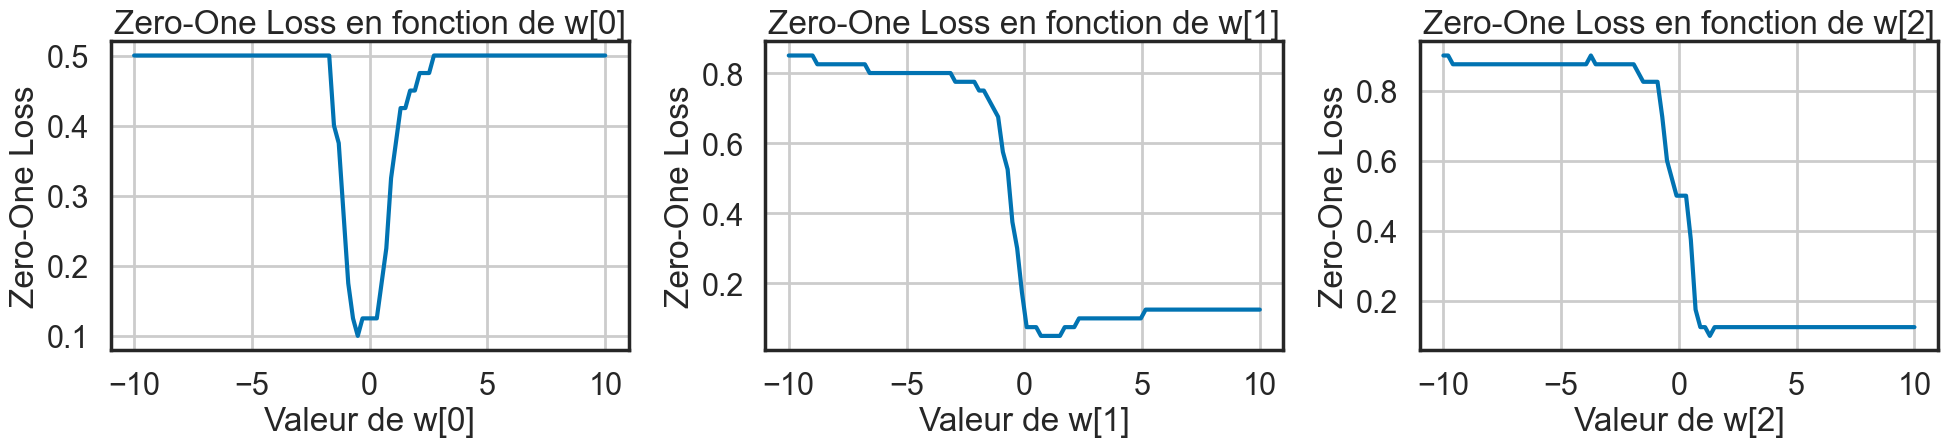

In [98]:

# Fonction prédictive compatible avec données AVEC biais
def predict_1(x, w):
    return np.dot(x, w)

# Zero-One Loss
def zero_one_loss_1(x, y, w):
    predictions = np.sign(predict_1(x, w))
    return np.mean(predictions != y)

# Tracé
fig, axes = plt.subplots(1, len(w), figsize=(20, 5))

for i in range(len(w)):
    weight_values = np.linspace(-10, 10, 100)
    zero_one_losses = []

    for val in weight_values:
        w_temp = w.copy()
        w_temp[i] = val
        zol = zero_one_loss_1(X_bi_gauss_with_bias, Y_bi_gauss, w_temp)
        zero_one_losses.append(zol)

    axes[i].plot(weight_values, zero_one_losses)
    axes[i].set_xlabel(f'Valeur de w[{i}]')
    axes[i].set_ylabel('Zero-One Loss')
    axes[i].set_title(f'Zero-One Loss en fonction de w[{i}]')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Dans le graphique où W[0], les changements abrupts dans la valeur de la perte suggèrent une fonction qui est constante par morceaux. Cependant, il y a aussi des segments où la fonction change linéairement entre deux discontinuités. Cela indique que la fonction de perte est à la fois linéaire et constante par morceaux sur différents intervalles de w[0].

Ce comportement de w[0] est aussi valable pour w[1] et w[2].

La forme générale est : 

$$
\left\{
\begin{array}{ll}
c_1 & \text{pour } a \leq x < x_1 \\
m_1 x + b_1 & \text{pour } x_1 \leq x < x_2 \\
c_2 & \text{pour } x_2 \leq x < x_3 \\
m_2 x + b_2 & \text{pour } x_3 \leq x < x_4 \\
\vdots & \\
c_n & \text{pour } x_{2n-1} \leq x \leq b
\end{array}
\right.
$$


## 3.3. Hingeloss

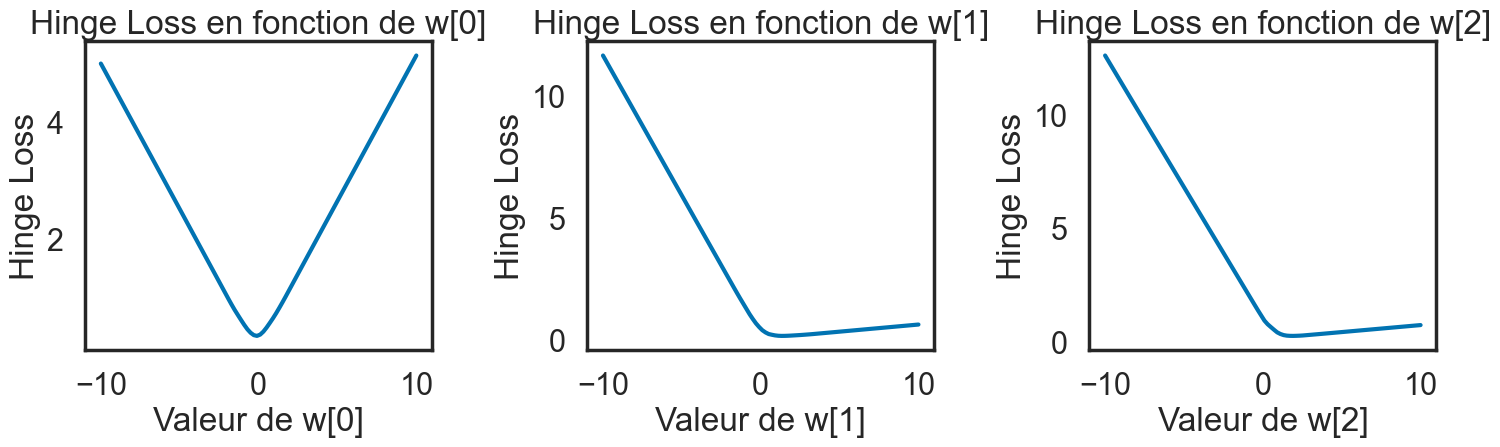

In [99]:
# Define the hinge loss function
def hinge_loss_1(y, x, w):
    hinge_loss = np.maximum(0, 1 - y * predict_1(x, w))
    return hinge_loss

fig, axes = plt.subplots(1, len(w), figsize=(15, 5))

# For each component of w, create a graph of the hinge loss
for i in range(len(w)):
    weight_values = np.linspace(-10, 10, 100)
    hinge_losses = []
    
    for val in weight_values:
        w_temp = w.copy()
        w_temp[i] = val
        hl = hinge_loss_1(Y_bi_gauss, X_bi_gauss_with_bias, w_temp)
        hinge_losses.append(np.mean(hl))  # Append the mean of the hinge losses

    # Plot the curve for the ith weight component on the ith subplot
    ax = axes[i]
    ax.plot(weight_values, hinge_losses)
    ax.set_xlabel(f'Valeur de w[{i}]')
    ax.set_ylabel('Hinge Loss')
    ax.set_title(f'Hinge Loss en fonction de w[{i}]')

plt.tight_layout()
plt.show()

Comparé avec les courbes de MSE, celles de Hinge Loss a une allure d'une fonction quadratique aussi. Mais il y a lieu de souligner qu'elles ne sont pas exactement quatratiques. 

En effet, d'une intervalle donnée, la fonction est d'abord une droite décroissante. A un moment, donné, elles ont une concavité avant de devenir une droite croissante. Chaque graphique montre une fonction qui semble être composée de deux lignes qui se rejoignent en un point formant un "V". Celà suggère une forme quadratique par morceaux.